In [2]:
# CELLULE A : Import et connexion

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import pyodbc
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
from matplotlib.ticker import FuncFormatter, MaxNLocator

print("="*70)
print("OBJECTIF 4 : PROMOTION IMPACT PREDICTION")
print("Prédiction de l'impact des promotions")
print("="*70)

# Connexion SQL Server
SERVER = 'LAPTOP-MPK2261L'
DATABASE = 'dw_pi'

try:
    conn_str = f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={SERVER};DATABASE={DATABASE};Trusted_Connection=yes'
    conn = pyodbc.connect(conn_str, timeout=30)
    print("✅ Connecté avec ODBC Driver 17")
except:
    try:
        conn_str = f'DRIVER={{SQL Server}};SERVER={SERVER};DATABASE={DATABASE};Trusted_Connection=yes'
        conn = pyodbc.connect(conn_str, timeout=30)
        print("✅ Connecté avec SQL Server")
    except Exception as e:
        print(f"❌ Erreur: {e}")
        conn = None

if conn is None:
    print("❌ Impossible de se connecter")
    exit()

OBJECTIF 4 : PROMOTION IMPACT PREDICTION
Prédiction de l'impact des promotions
✅ Connecté avec ODBC Driver 17


In [3]:
# CELLULE B : Extraction des données

print("\n📊 Extraction des données...")

query = """
SELECT 
    s.pk_id_sale,
    d.full_date,
    s.fk_product,
    s.fk_clientB2B,
    s.fk_clientB2C,
    s.fk_channel,
    s.quantity,
    s.unit_price,
    s.discount,
    s.total_price,
    (s.total_price - s.discount) as net_amount,
    CASE WHEN s.discount > 0 THEN 1 ELSE 0 END as has_promotion,
    s.discount / NULLIF(s.total_price, 0) as discount_rate,
    p.name_product,
    c.name_category
FROM fact_sale s
INNER JOIN dim_date d ON s.fk_date = d.pk_id_date
INNER JOIN dim_product p ON s.fk_product = p.pk_id_product
LEFT JOIN dim_category c ON p.fk_category = c.pk_id_category
WHERE s.quantity IS NOT NULL
"""

df = pd.read_sql(query, conn)
conn.close()

# Nettoyage
df['full_date'] = pd.to_datetime(df['full_date'])
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce').fillna(0).astype(int)
df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce').fillna(0)
df['discount'] = pd.to_numeric(df['discount'], errors='coerce').fillna(0)
df['total_price'] = pd.to_numeric(df['total_price'], errors='coerce').fillna(0)
df['net_amount'] = pd.to_numeric(df['net_amount'], errors='coerce').fillna(0)
df['discount_rate'] = pd.to_numeric(df['discount_rate'], errors='coerce').fillna(0)
df['has_promotion'] = df['has_promotion'].astype(int)

# Valeurs manquantes
df['name_category'] = df['name_category'].fillna('Non catégorisé')

print(f"✅ {len(df):,} transactions extraites")
print(f"📅 Période : {df['full_date'].min().date()} → {df['full_date'].max().date()}")
print(f"💰 Total CA : {df['net_amount'].sum():,.2f} DT")
print(f"🎯 Transactions avec promotion : {df['has_promotion'].sum():,} ({df['has_promotion'].mean()*100:.1f}%)")


📊 Extraction des données...
✅ 60 transactions extraites
📅 Période : 2023-12-30 → 2026-01-02
💰 Total CA : 5,630.51 DT
🎯 Transactions avec promotion : 0 (0.0%)



📊 DATA PREPARATION & FEATURE ENGINEERING - OBJECTIF 4

1. DATA CLEANING
----------------------------------------
Valeurs manquantes avant traitement :
pk_id_sale       0
full_date        0
fk_product       0
fk_clientB2B     0
fk_clientB2C     0
fk_channel       0
quantity         0
unit_price       0
discount         0
total_price      0
net_amount       0
has_promotion    0
discount_rate    0
name_product     0
name_category    0
dtype: int64
✅ Après suppression des NaN critiques : 60 lignes
✅ Outliers sur 'quantity' : 2 (clipping appliqué)

2. CRÉATION DES FEATURES TEMPORELLES
----------------------------------------
✅ Features temporelles créées : day_of_week, month, is_weekend

3. FEATURE ENGINEERING
----------------------------------------
✅ Nouvelles features créées : price_per_unit, discount_amount, month_sin, month_cos, category_encoded, channel_encoded

4. FEATURE SELECTION (Filter method)
----------------------------------------
Corrélation absolue des features avec 'quanti

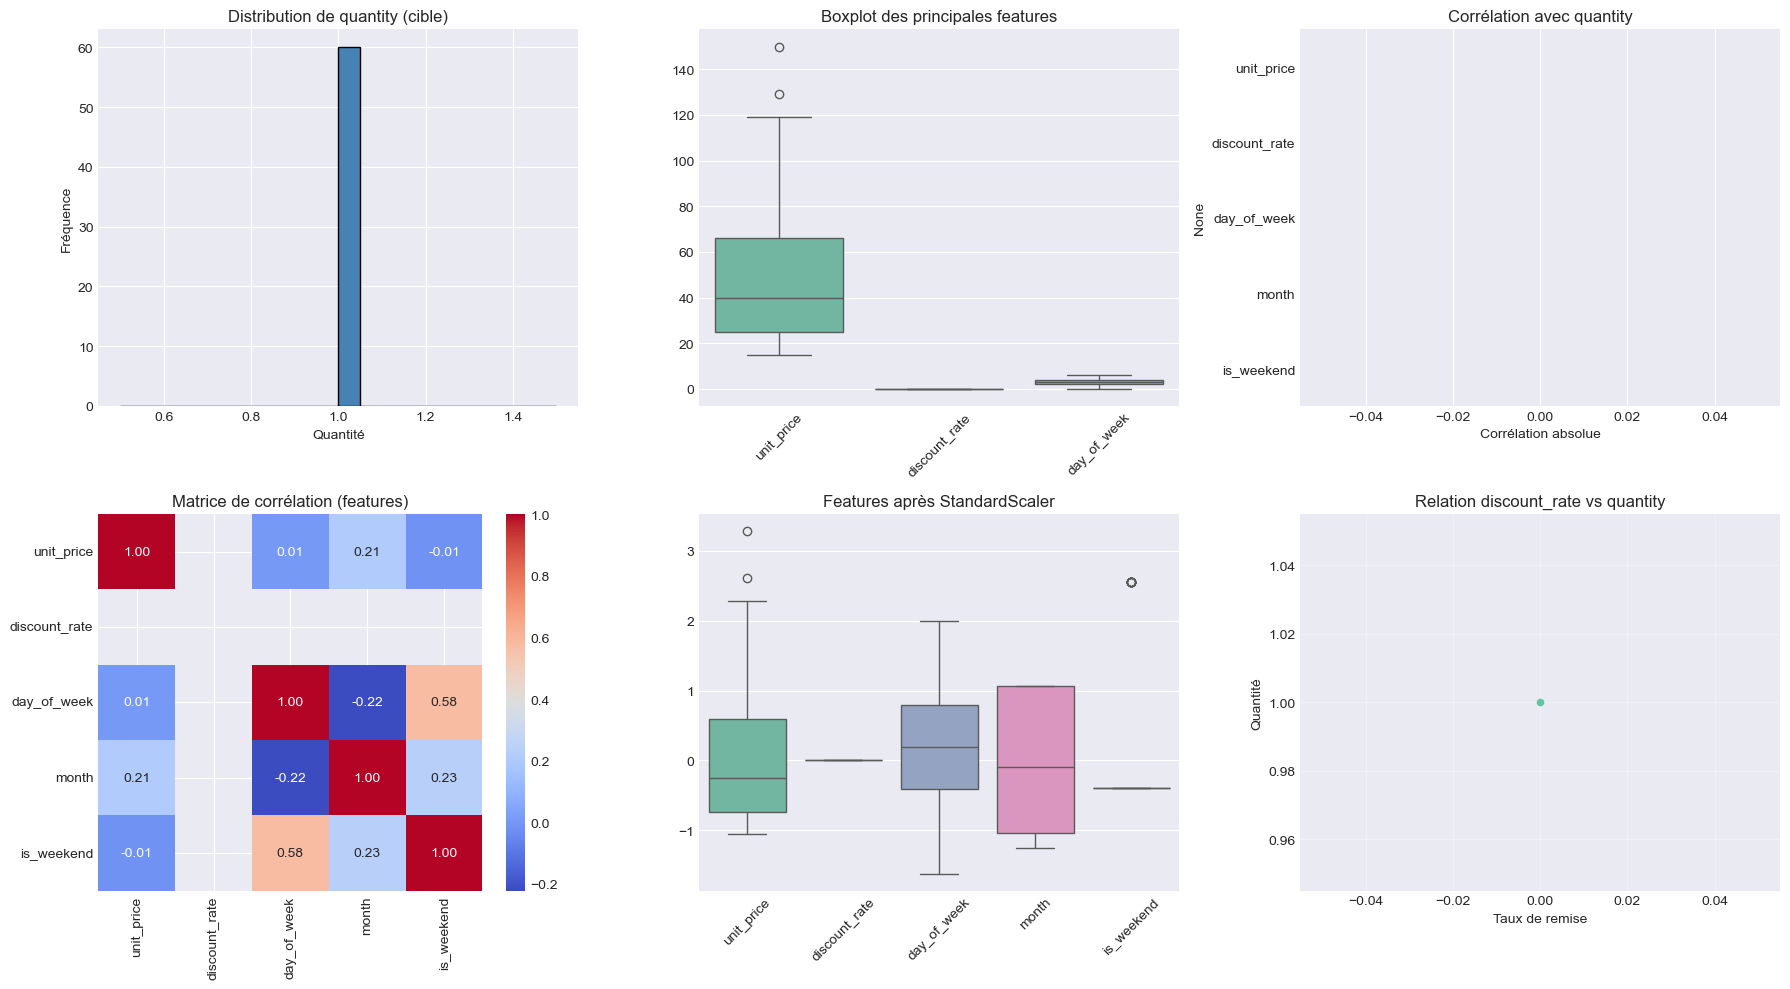


✅ Data Preparation & Feature Engineering terminé
   Features finales : ['unit_price', 'discount_rate', 'day_of_week', 'month', 'is_weekend']
   Nombre d'observations : 60


In [5]:
# CELLULE 4.1bis : DATA PREPARATION & FEATURE ENGINEERING - OBJECTIF 4 (CORRIGÉE)

print("\n" + "="*70)
print("📊 DATA PREPARATION & FEATURE ENGINEERING - OBJECTIF 4")
print("="*70)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. DATA CLEANING
# ============================================

print("\n1. DATA CLEANING")
print("-"*40)

# Vérifier que df existe
if 'df' not in locals():
    print("❌ Le DataFrame 'df' n'existe pas. Exécutez d'abord la cellule d'extraction.")
    exit()

# Sélection des colonnes pertinentes pour la régression
df_clean = df.copy()

# Valeurs manquantes
print(f"Valeurs manquantes avant traitement :")
print(df_clean.isnull().sum())

# Suppression des lignes avec valeurs manquantes critiques (si peu)
df_clean = df_clean.dropna(subset=['quantity', 'unit_price', 'discount_rate', 'net_amount'])
print(f"✅ Après suppression des NaN critiques : {len(df_clean)} lignes")

# Détection et traitement des outliers sur la cible (quantity)
Q1 = df_clean['quantity'].quantile(0.25)
Q3 = df_clean['quantity'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = ((df_clean['quantity'] < lower) | (df_clean['quantity'] > upper)).sum()
print(f"✅ Outliers sur 'quantity' : {outliers} (clipping appliqué)")
df_clean['quantity'] = df_clean['quantity'].clip(lower=lower, upper=upper)

# ============================================
# 2. CRÉATION DES FEATURES TEMPORELLES
# ============================================

print("\n2. CRÉATION DES FEATURES TEMPORELLES")
print("-"*40)

# Convertir full_date en datetime si ce n'est pas déjà fait
if 'full_date' in df_clean.columns:
    df_clean['full_date'] = pd.to_datetime(df_clean['full_date'])
    df_clean['day_of_week'] = df_clean['full_date'].dt.dayofweek
    df_clean['month'] = df_clean['full_date'].dt.month
    df_clean['is_weekend'] = (df_clean['day_of_week'] >= 5).astype(int)
    print("✅ Features temporelles créées : day_of_week, month, is_weekend")
else:
    # Si la colonne full_date n'existe pas, on vérifie si date existe
    if 'date' in df_clean.columns:
        df_clean['full_date'] = pd.to_datetime(df_clean['date'])
        df_clean['day_of_week'] = df_clean['full_date'].dt.dayofweek
        df_clean['month'] = df_clean['full_date'].dt.month
        df_clean['is_weekend'] = (df_clean['day_of_week'] >= 5).astype(int)
        print("✅ Features temporelles créées : day_of_week, month, is_weekend")
    else:
        print("⚠️ Colonne de date non trouvée, création de features temporelles par défaut")
        df_clean['day_of_week'] = 0
        df_clean['month'] = 1
        df_clean['is_weekend'] = 0

# ============================================
# 3. FEATURE ENGINEERING
# ============================================

print("\n3. FEATURE ENGINEERING")
print("-"*40)

# Création de nouvelles features
df_clean['price_per_unit'] = df_clean['unit_price']  # déjà présent
df_clean['discount_amount'] = df_clean['discount']
df_clean['weekend'] = df_clean['is_weekend']
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month'] / 12)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['month'] / 12)

# Encodage des variables catégorielles
if 'name_category' in df_clean.columns:
    le = LabelEncoder()
    df_clean['category_encoded'] = le.fit_transform(df_clean['name_category'].astype(str))
else:
    df_clean['category_encoded'] = 0

if 'fk_channel' in df_clean.columns:
    df_clean['channel_encoded'] = df_clean['fk_channel'].fillna(0).astype('category').cat.codes
else:
    df_clean['channel_encoded'] = 0

print(f"✅ Nouvelles features créées : price_per_unit, discount_amount, month_sin, month_cos, category_encoded, channel_encoded")

# ============================================
# 4. FEATURE SELECTION (Filter method - corrélation avec la cible)
# ============================================

print("\n4. FEATURE SELECTION (Filter method)")
print("-"*40)

# Sélection des features numériques
numeric_features = ['unit_price', 'discount_rate', 'day_of_week', 'month', 'is_weekend', 
                    'price_per_unit', 'discount_amount', 'month_sin', 'month_cos', 
                    'category_encoded', 'channel_encoded']

# Corrélation avec la cible 'quantity'
correlations = df_clean[numeric_features + ['quantity']].corr()['quantity'].drop('quantity').abs().sort_values(ascending=False)
print("Corrélation absolue des features avec 'quantity' :")
for feat, corr in correlations.items():
    print(f"   {feat}: {corr:.4f}")

# Sélection des features avec corrélation > 0.05
selected_features = correlations[correlations > 0.05].index.tolist()
print(f"\n✅ Features retenues par corrélation (>0.05) : {selected_features}")

# Si aucune feature n'est retenue, on garde les 5 meilleures
if len(selected_features) == 0:
    selected_features = correlations.head(5).index.tolist()
    print(f"⚠️ Aucune corrélation >0.05, utilisation des 5 meilleures : {selected_features}")

# ============================================
# 5. SCALING
# ============================================

print("\n5. SCALING (StandardScaler)")
print("-"*40)

X = df_clean[selected_features].copy()
y = df_clean['quantity']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=selected_features)

print(f"✅ Données normalisées : shape {X_scaled.shape}")
print(f"   Moyennes : {X_scaled.mean().round(4).values}")
print(f"   Écarts-types : {X_scaled.std().round(4).values}")

# ============================================
# 6. VISUALISATIONS
# ============================================

print("\n6. VISUALISATIONS")
print("-"*40)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribution de la cible (quantity)
axes[0,0].hist(df_clean['quantity'], bins=20, color='steelblue', edgecolor='black')
axes[0,0].set_title('Distribution de quantity (cible)')
axes[0,0].set_xlabel('Quantité')
axes[0,0].set_ylabel('Fréquence')

# 2. Boxplot des features sélectionnées (limité à 3 pour lisibilité)
if len(selected_features) >= 3:
    sns.boxplot(data=df_clean[selected_features[:3]], ax=axes[0,1])
    axes[0,1].set_title('Boxplot des principales features')
    axes[0,1].tick_params(axis='x', rotation=45)
else:
    axes[0,1].axis('off')

# 3. Corrélation des features sélectionnées avec la cible
sns.barplot(x=correlations[selected_features].values, y=correlations[selected_features].index, ax=axes[0,2], palette='viridis')
axes[0,2].set_title('Corrélation avec quantity')
axes[0,2].set_xlabel('Corrélation absolue')

# 4. Heatmap des corrélations entre features sélectionnées
if len(selected_features) > 1:
    sns.heatmap(df_clean[selected_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1,0])
    axes[1,0].set_title('Matrice de corrélation (features)')
else:
    axes[1,0].axis('off')

# 5. Distribution des features après scaling
sns.boxplot(data=X_scaled, ax=axes[1,1])
axes[1,1].set_title('Features après StandardScaler')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Relation entre discount_rate et quantity
sns.scatterplot(data=df_clean, x='discount_rate', y='quantity', alpha=0.5, ax=axes[1,2])
axes[1,2].set_title('Relation discount_rate vs quantity')
axes[1,2].set_xlabel('Taux de remise')
axes[1,2].set_ylabel('Quantité')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 7. MISE À JOUR DES VARIABLES POUR LA MODÉLISATION
# ============================================

print("\n✅ Data Preparation & Feature Engineering terminé")
print(f"   Features finales : {selected_features}")
print(f"   Nombre d'observations : {len(X_scaled)}")

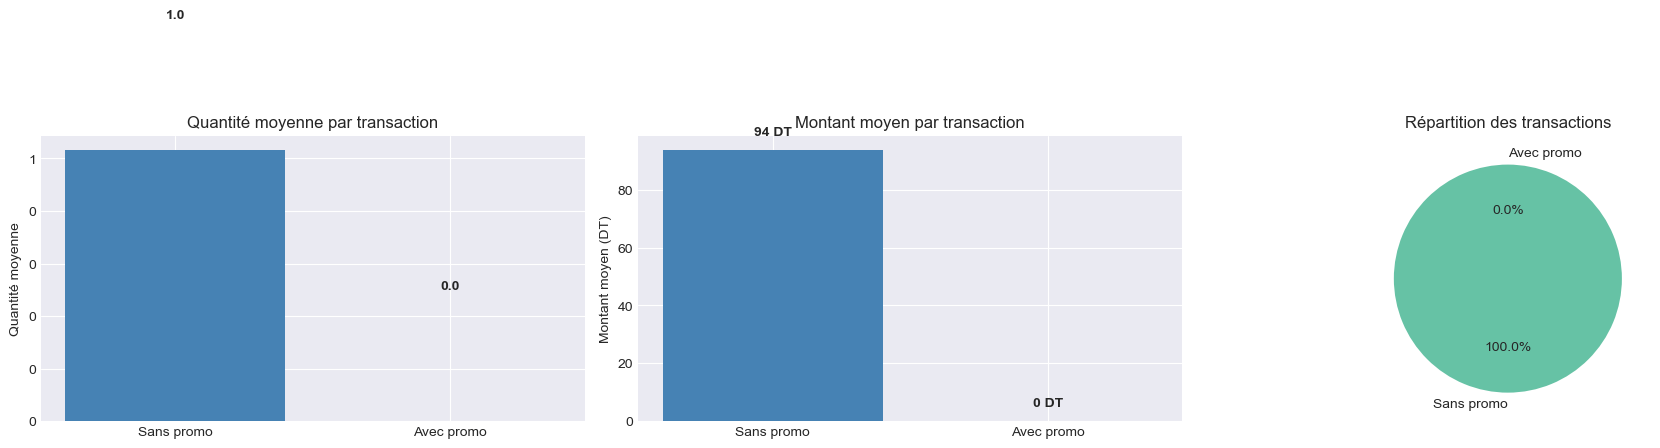


📊 IMPACT DES PROMOTIONS :


In [12]:
# CELLULE C : Graphique 1 - Impact des promotions

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Comparaison quantité
promo_quantity = df.groupby('has_promotion')['quantity'].mean()
promo_labels = ['Sans promo', 'Avec promo']
promo_values = [promo_quantity.get(0, 0), promo_quantity.get(1, 0)]

axes[0].bar(promo_labels, promo_values, color=['steelblue', 'coral'])
axes[0].set_title('Quantité moyenne par transaction', fontsize=12)
axes[0].set_ylabel('Quantité moyenne')
for i, v in enumerate(promo_values):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x)}'))

# Comparaison montant
promo_amount = df.groupby('has_promotion')['net_amount'].mean()
promo_amount_values = [promo_amount.get(0, 0), promo_amount.get(1, 0)]

axes[1].bar(promo_labels, promo_amount_values, color=['steelblue', 'coral'])
axes[1].set_title('Montant moyen par transaction', fontsize=12)
axes[1].set_ylabel('Montant moyen (DT)')
for i, v in enumerate(promo_amount_values):
    axes[1].text(i, v + 5, f'{v:.0f} DT', ha='center', fontweight='bold')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x)}'))

# Répartition
transactions_count = df.groupby('has_promotion').size()
transactions_values = [transactions_count.get(0, 0), transactions_count.get(1, 0)]

if sum(transactions_values) > 0:
    axes[2].pie(transactions_values, labels=promo_labels, autopct='%1.1f%%', startangle=90)
else:
    axes[2].text(0.5, 0.5, 'Aucune donnée', ha='center', va='center', fontsize=12)
axes[2].set_title('Répartition des transactions', fontsize=12)

plt.tight_layout()
plt.show()

print("\n📊 IMPACT DES PROMOTIONS :")
if promo_values[0] > 0 and promo_values[1] > 0:
    qty_increase = (promo_values[1] / promo_values[0] - 1) * 100
    amount_increase = (promo_amount_values[1] / promo_amount_values[0] - 1) * 100
    print(f"   Quantité moyenne : +{qty_increase:.1f}% avec promotion")
    print(f"   Montant moyen : +{amount_increase:.1f}% avec promotion")

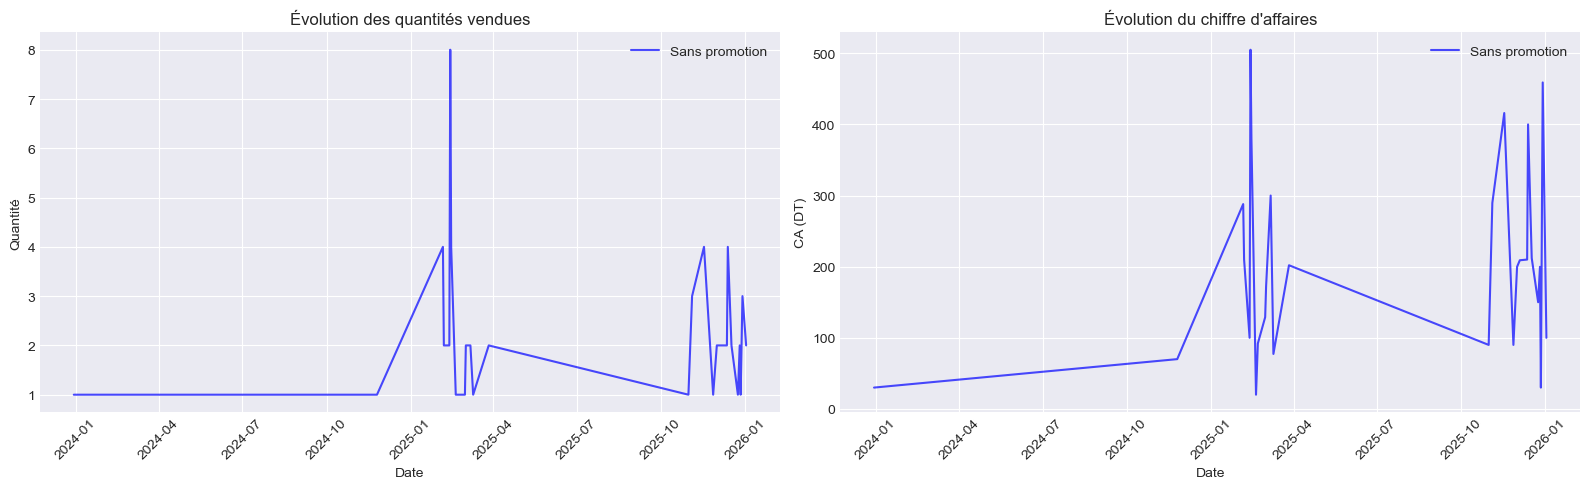

In [13]:
# CELLULE D : Graphique 2 - Évolution temporelle

df['date'] = df['full_date'].dt.date
daily = df.groupby(['date', 'has_promotion']).agg({
    'quantity': 'sum',
    'net_amount': 'sum'
}).reset_index()

daily_promo = daily[daily['has_promotion'] == 1].set_index('date')
daily_no_promo = daily[daily['has_promotion'] == 0].set_index('date')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Quantité
if len(daily_no_promo) > 0:
    axes[0].plot(daily_no_promo.index, daily_no_promo['quantity'], 'b-', label='Sans promotion', alpha=0.7)
if len(daily_promo) > 0:
    axes[0].plot(daily_promo.index, daily_promo['quantity'], 'r-', label='Avec promotion', alpha=0.7)
axes[0].set_title('Évolution des quantités vendues', fontsize=12)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Quantité')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x)}'))

# Montant
if len(daily_no_promo) > 0:
    axes[1].plot(daily_no_promo.index, daily_no_promo['net_amount'], 'b-', label='Sans promotion', alpha=0.7)
if len(daily_promo) > 0:
    axes[1].plot(daily_promo.index, daily_promo['net_amount'], 'r-', label='Avec promotion', alpha=0.7)
axes[1].set_title('Évolution du chiffre d\'affaires', fontsize=12)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('CA (DT)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x)}'))

plt.tight_layout()
plt.show()


📊 GRAPHIQUE 3 : IMPACT DES PROMOTIONS PAR CATÉGORIE
Nombre total de transactions : 60
Transactions avec promotion : 0
Catégories uniques : 11
⚠️ Aucune transaction avec promotion - Impossible d'analyser l'impact


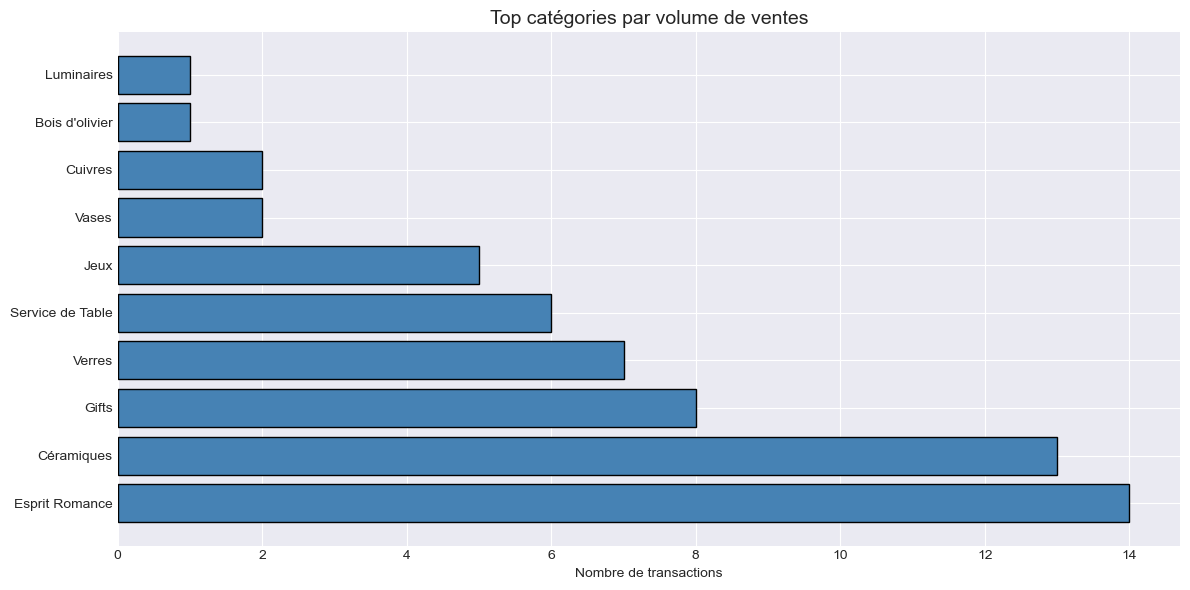

In [17]:
# CELLULE E3 : Graphique 3 - Impact des promotions par catégorie

print("\n" + "="*70)
print("📊 GRAPHIQUE 3 : IMPACT DES PROMOTIONS PAR CATÉGORIE")
print("="*70)

# Vérifier les données
print(f"Nombre total de transactions : {len(df)}")
print(f"Transactions avec promotion : {df['has_promotion'].sum()}")
print(f"Catégories uniques : {df['name_category'].nunique()}")

if df['has_promotion'].sum() > 0:
    # Calculer la quantité moyenne par catégorie avec/sans promotion
    category_promo = df[df['has_promotion'] == 1].groupby('name_category')['quantity'].mean().reset_index()
    category_promo.columns = ['name_category', 'qty_with_promo']
    
    category_no_promo = df[df['has_promotion'] == 0].groupby('name_category')['quantity'].mean().reset_index()
    category_no_promo.columns = ['name_category', 'qty_without_promo']
    
    # Fusionner
    category_compare = pd.merge(category_promo, category_no_promo, on='name_category', how='inner')
    
    # Calculer l'augmentation
    category_compare['increase'] = ((category_compare['qty_with_promo'] - category_compare['qty_without_promo']) / category_compare['qty_without_promo'].replace(0, 1)) * 100
    category_compare = category_compare.sort_values('increase', ascending=False).head(10)
    
    if len(category_compare) > 0:
        # CRÉATION DU GRAPHIQUE
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        
        # Graphique 1 : Augmentation en pourcentage (barres horizontales)
        colors = ['green' if v > 0 else 'red' for v in category_compare['increase']]
        bars1 = axes[0].barh(range(len(category_compare)), category_compare['increase'], color=colors, edgecolor='black')
        axes[0].set_yticks(range(len(category_compare)))
        axes[0].set_yticklabels([c[:30] for c in category_compare['name_category']])
        axes[0].set_title('Augmentation des ventes par catégorie avec promotion (%)', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Augmentation (%)', fontsize=12)
        axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1.5)
        axes[0].grid(True, alpha=0.3, axis='x')
        
        # Ajouter les valeurs sur les barres
        for i, (bar, val) in enumerate(zip(bars1, category_compare['increase'])):
            axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                        f'{val:.0f}%', va='center', fontweight='bold', fontsize=10)
        
        # Graphique 2 : Quantité avec vs sans promotion (barres groupées)
        x = np.arange(len(category_compare))
        width = 0.35
        
        bars2 = axes[1].bar(x - width/2, category_compare['qty_without_promo'], width, 
                            label='Sans promotion', color='steelblue', edgecolor='black')
        bars3 = axes[1].bar(x + width/2, category_compare['qty_with_promo'], width, 
                            label='Avec promotion', color='coral', edgecolor='black')
        
        axes[1].set_xticks(x)
        axes[1].set_xticklabels([c[:20] for c in category_compare['name_category']], rotation=45, ha='right')
        axes[1].set_title('Quantité moyenne vendue par catégorie', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Catégorie', fontsize=12)
        axes[1].set_ylabel('Quantité moyenne (unités)', fontsize=12)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3, axis='y')
        axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x)}'))
        
        plt.tight_layout()
        plt.show()
        
        # Afficher les résultats
        print("\n📊 TOP CATÉGORIES LES PLUS SENSIBLES AUX PROMOTIONS :")
        print("-"*60)
        for i, row in category_compare.iterrows():
            print(f"   📌 {row['name_category'][:40]}")
            print(f"      Quantité sans promo : {row['qty_without_promo']:.1f} | Avec promo : {row['qty_with_promo']:.1f} | +{row['increase']:.0f}%")
        
    else:
        print("⚠️ Pas assez de données pour comparer les catégories")
        print("   (Besoin de catégories avec des transactions avec et sans promotion)")
else:
    print("⚠️ Aucune transaction avec promotion - Impossible d'analyser l'impact")
    
    # Afficher un graphique alternatif
    plt.figure(figsize=(12, 6))
    category_counts = df['name_category'].value_counts().head(10)
    plt.barh(range(len(category_counts)), category_counts.values, color='steelblue', edgecolor='black')
    plt.yticks(range(len(category_counts)), [c[:30] for c in category_counts.index])
    plt.title('Top catégories par volume de ventes', fontsize=14)
    plt.xlabel('Nombre de transactions')
    plt.tight_layout()
    plt.show()

In [48]:
# CELLULE C : Préparation des données

print("\n" + "="*70)
print("PRÉPARATION DES DONNÉES POUR ML")
print("="*70)

# Créer les features
df['day_of_week'] = df['full_date'].dt.dayofweek
df['month'] = df['full_date'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['category_encoded'] = df['name_category'].astype('category').cat.codes
df['channel_encoded'] = df['fk_channel'].fillna(0).astype('category').cat.codes

# Features
features = ['discount_rate', 'unit_price', 'day_of_week', 'month', 'is_weekend', 
            'category_encoded', 'channel_encoded']

# Cibles
target_quantity = df['quantity']
target_amount = df['net_amount']

# Nettoyage
X = df[features].copy()
X = X.replace([np.inf, -np.inf], 0)
X = X.fillna(0)

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split pour la quantité
X_train, X_test, y_train_q, y_test_q = train_test_split(X_scaled, target_quantity, test_size=0.2, random_state=42)

# Split pour le montant (même split pour garder la cohérence)
_, _, y_train_a, y_test_a = train_test_split(X_scaled, target_amount, test_size=0.2, random_state=42)

print(f"✅ Données préparées : {len(X)} transactions")
print(f"📊 Features : {features}")
print(f"📈 Train : {len(X_train)} | Test : {len(X_test)}")
print(f"📊 y_train_q : {len(y_train_q)} | y_train_a : {len(y_train_a)}")


PRÉPARATION DES DONNÉES POUR ML
✅ Données préparées : 60 transactions
📊 Features : ['discount_rate', 'unit_price', 'day_of_week', 'month', 'is_weekend', 'category_encoded', 'channel_encoded']
📈 Train : 48 | Test : 12
📊 y_train_q : 48 | y_train_a : 48


In [49]:
# CELLULE I : Split des données

X_train, X_test, y_train_q, y_test_q = train_test_split(X_scaled, target_quantity, test_size=0.2, random_state=42)
_, _, y_train_b, y_test_b = train_test_split(X_scaled, target_basket, test_size=0.2, random_state=42)

print(f"📊 Train : {len(X_train)} | Test : {len(X_test)}")

📊 Train : 48 | Test : 12



🌳 MODÈLE 1 : DECISION TREE REGRESSOR

📈 Quantité : MAE=0.08 | R²=-0.0909
📈 Montant : MAE=17.76 DT | R²=0.3184


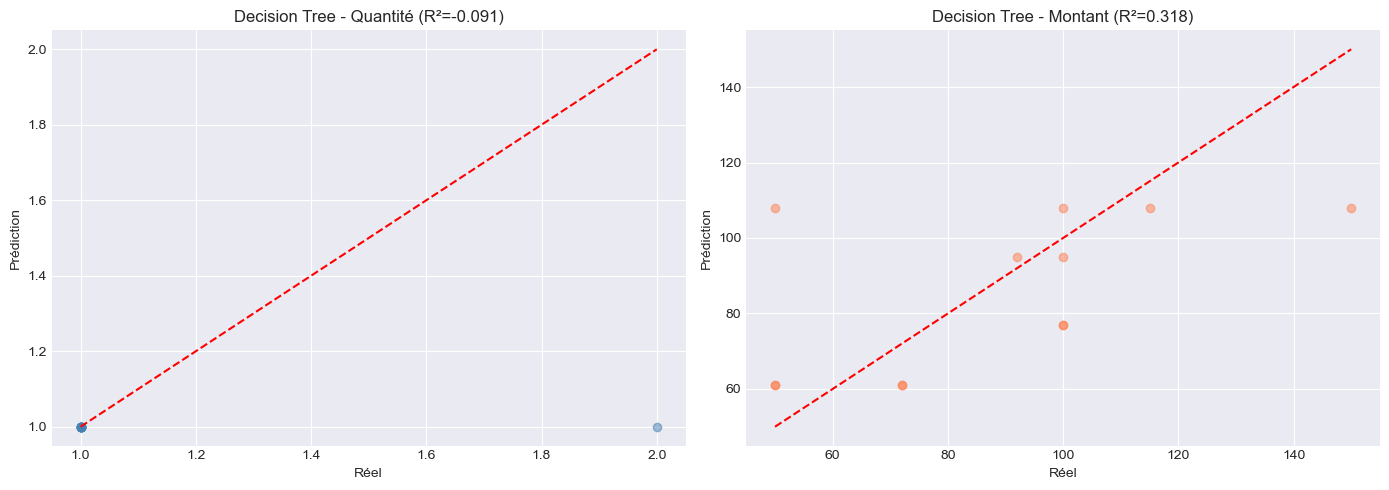

In [50]:
# CELLULE D : MODÈLE 1 - DECISION TREE

print("\n" + "="*70)
print("🌳 MODÈLE 1 : DECISION TREE REGRESSOR")
print("="*70)

# Quantité
dt_q = DecisionTreeRegressor(max_depth=5, min_samples_split=5, random_state=42)
dt_q.fit(X_train, y_train_q)
y_pred_dt_q = np.round(dt_q.predict(X_test)).astype(int)

# Montant
dt_a = DecisionTreeRegressor(max_depth=5, min_samples_split=5, random_state=42)
dt_a.fit(X_train, y_train_a)
y_pred_dt_a = np.round(dt_a.predict(X_test)).astype(int)

# Évaluations
mae_dt_q = mean_absolute_error(y_test_q, y_pred_dt_q)
r2_dt_q = r2_score(y_test_q, y_pred_dt_q)
mae_dt_a = mean_absolute_error(y_test_a, y_pred_dt_a)
r2_dt_a = r2_score(y_test_a, y_pred_dt_a)

print(f"\n📈 Quantité : MAE={mae_dt_q:.2f} | R²={r2_dt_q:.4f}")
print(f"📈 Montant : MAE={mae_dt_a:.2f} DT | R²={r2_dt_a:.4f}")

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test_q, y_pred_dt_q, alpha=0.5, color='steelblue')
axes[0].plot([y_test_q.min(), y_test_q.max()], [y_test_q.min(), y_test_q.max()], 'r--')
axes[0].set_title(f'Decision Tree - Quantité (R²={r2_dt_q:.3f})')
axes[0].set_xlabel('Réel')
axes[0].set_ylabel('Prédiction')

axes[1].scatter(y_test_a, y_pred_dt_a, alpha=0.5, color='coral')
axes[1].plot([y_test_a.min(), y_test_a.max()], [y_test_a.min(), y_test_a.max()], 'r--')
axes[1].set_title(f'Decision Tree - Montant (R²={r2_dt_a:.3f})')
axes[1].set_xlabel('Réel')
axes[1].set_ylabel('Prédiction')

plt.tight_layout()
plt.show()


🌲 MODÈLE 2 : RANDOM FOREST REGRESSOR

📈 Quantité : MAE=0.08 | R²=-0.0909
📈 Montant : MAE=10.24 DT | R²=0.8170


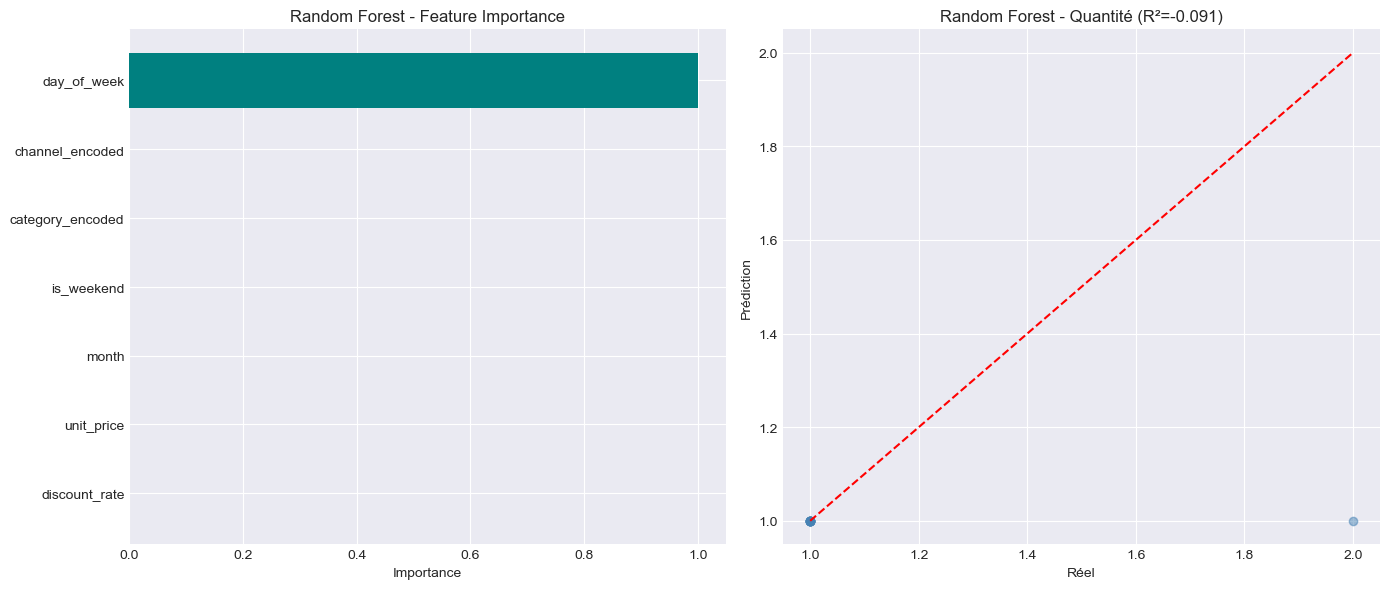

In [51]:
# CELLULE E : MODÈLE 2 - RANDOM FOREST

print("\n" + "="*70)
print("🌲 MODÈLE 2 : RANDOM FOREST REGRESSOR")
print("="*70)

# Quantité
rf_q = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_q.fit(X_train, y_train_q)
y_pred_rf_q = np.round(rf_q.predict(X_test)).astype(int)

# Montant
rf_a = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_a.fit(X_train, y_train_a)
y_pred_rf_a = np.round(rf_a.predict(X_test)).astype(int)

# Évaluations
mae_rf_q = mean_absolute_error(y_test_q, y_pred_rf_q)
r2_rf_q = r2_score(y_test_q, y_pred_rf_q)
mae_rf_a = mean_absolute_error(y_test_a, y_pred_rf_a)
r2_rf_a = r2_score(y_test_a, y_pred_rf_a)

print(f"\n📈 Quantité : MAE={mae_rf_q:.2f} | R²={r2_rf_q:.4f}")
print(f"📈 Montant : MAE={mae_rf_a:.2f} DT | R²={r2_rf_a:.4f}")

# Feature Importance
importance_rf = pd.DataFrame({'feature': features, 'importance': rf_q.feature_importances_}).sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(importance_rf['feature'], importance_rf['importance'], color='teal')
axes[0].set_title('Random Forest - Feature Importance')
axes[0].set_xlabel('Importance')

axes[1].scatter(y_test_q, y_pred_rf_q, alpha=0.5, color='steelblue')
axes[1].plot([y_test_q.min(), y_test_q.max()], [y_test_q.min(), y_test_q.max()], 'r--')
axes[1].set_title(f'Random Forest - Quantité (R²={r2_rf_q:.3f})')
axes[1].set_xlabel('Réel')
axes[1].set_ylabel('Prédiction')

plt.tight_layout()
plt.show()


⚡ MODÈLE 3 : GRADIENT BOOSTING REGRESSOR

📈 Quantité : MAE=0.08 | R²=-0.0909
📈 Montant : MAE=6.49 DT | R²=0.7489


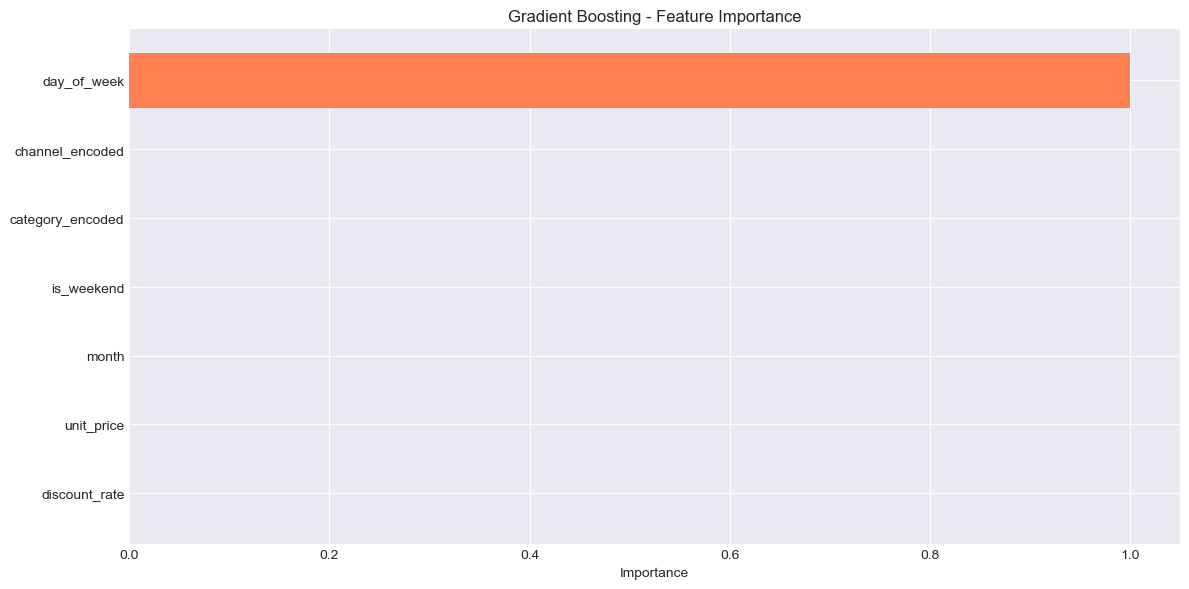

In [52]:
# CELLULE F : MODÈLE 3 - GRADIENT BOOSTING

print("\n" + "="*70)
print("⚡ MODÈLE 3 : GRADIENT BOOSTING REGRESSOR")
print("="*70)

# Quantité
gb_q = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_q.fit(X_train, y_train_q)
y_pred_gb_q = np.round(gb_q.predict(X_test)).astype(int)

# Montant
gb_a = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_a.fit(X_train, y_train_a)
y_pred_gb_a = np.round(gb_a.predict(X_test)).astype(int)

# Évaluations
mae_gb_q = mean_absolute_error(y_test_q, y_pred_gb_q)
r2_gb_q = r2_score(y_test_q, y_pred_gb_q)
mae_gb_a = mean_absolute_error(y_test_a, y_pred_gb_a)
r2_gb_a = r2_score(y_test_a, y_pred_gb_a)

print(f"\n📈 Quantité : MAE={mae_gb_q:.2f} | R²={r2_gb_q:.4f}")
print(f"📈 Montant : MAE={mae_gb_a:.2f} DT | R²={r2_gb_a:.4f}")

# Feature Importance
importance_gb = pd.DataFrame({'feature': features, 'importance': gb_q.feature_importances_}).sort_values('importance', ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(importance_gb['feature'], importance_gb['importance'], color='coral')
plt.title('Gradient Boosting - Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


🚀 MODÈLE 4 : XGBOOST

📈 Quantité : MAE=0.08 | R²=-0.0909
📈 Montant : MAE=6.84 DT | R²=0.7871


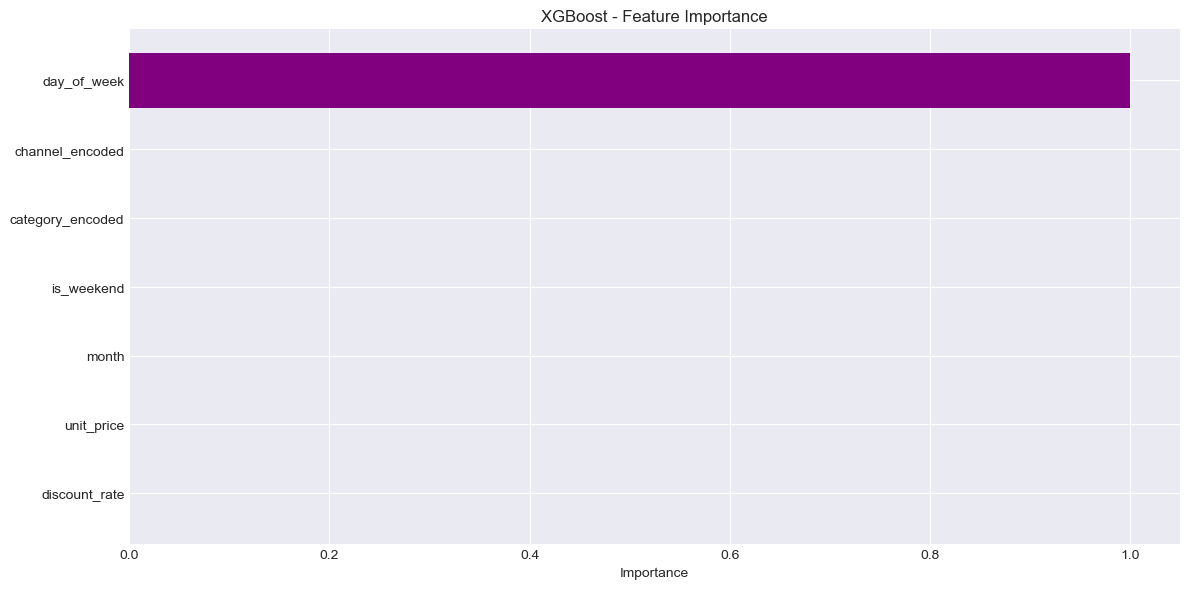

In [53]:
# CELLULE G : MODÈLE 4 - XGBOOST

print("\n" + "="*70)
print("🚀 MODÈLE 4 : XGBOOST")
print("="*70)

try:
    import xgboost as xgb
    
    # Quantité
    xgb_q = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
    xgb_q.fit(X_train, y_train_q)
    y_pred_xgb_q = np.round(xgb_q.predict(X_test)).astype(int)
    
    # Montant
    xgb_a = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
    xgb_a.fit(X_train, y_train_a)
    y_pred_xgb_a = np.round(xgb_a.predict(X_test)).astype(int)
    
    # Évaluations
    mae_xgb_q = mean_absolute_error(y_test_q, y_pred_xgb_q)
    r2_xgb_q = r2_score(y_test_q, y_pred_xgb_q)
    mae_xgb_a = mean_absolute_error(y_test_a, y_pred_xgb_a)
    r2_xgb_a = r2_score(y_test_a, y_pred_xgb_a)
    
    print(f"\n📈 Quantité : MAE={mae_xgb_q:.2f} | R²={r2_xgb_q:.4f}")
    print(f"📈 Montant : MAE={mae_xgb_a:.2f} DT | R²={r2_xgb_a:.4f}")
    
    # Feature Importance
    importance_xgb = pd.DataFrame({'feature': features, 'importance': xgb_q.feature_importances_}).sort_values('importance', ascending=True)
    
    plt.figure(figsize=(12, 6))
    plt.barh(importance_xgb['feature'], importance_xgb['importance'], color='purple')
    plt.title('XGBoost - Feature Importance')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("❌ XGBoost non installé. Installation: pip install xgboost")
    mae_xgb_q, r2_xgb_q, mae_xgb_a, r2_xgb_a = 0, 0, 0, 0


📊 COMPARAISON DES MODÈLES ML

📊 TABLEAU COMPARATIF - Quantité :
           Modèle    MAE_Q      R²_Q
    Decision Tree 0.083333 -0.090909
    Random Forest 0.083333 -0.090909
Gradient Boosting 0.083333 -0.090909
          XGBoost 0.083333 -0.090909

📊 TABLEAU COMPARATIF - Montant :
           Modèle     MAE_A     R²_A
    Decision Tree 17.758333 0.318442
    Random Forest 10.241667 0.817040
Gradient Boosting  6.491667 0.748891
          XGBoost  6.841667 0.787074


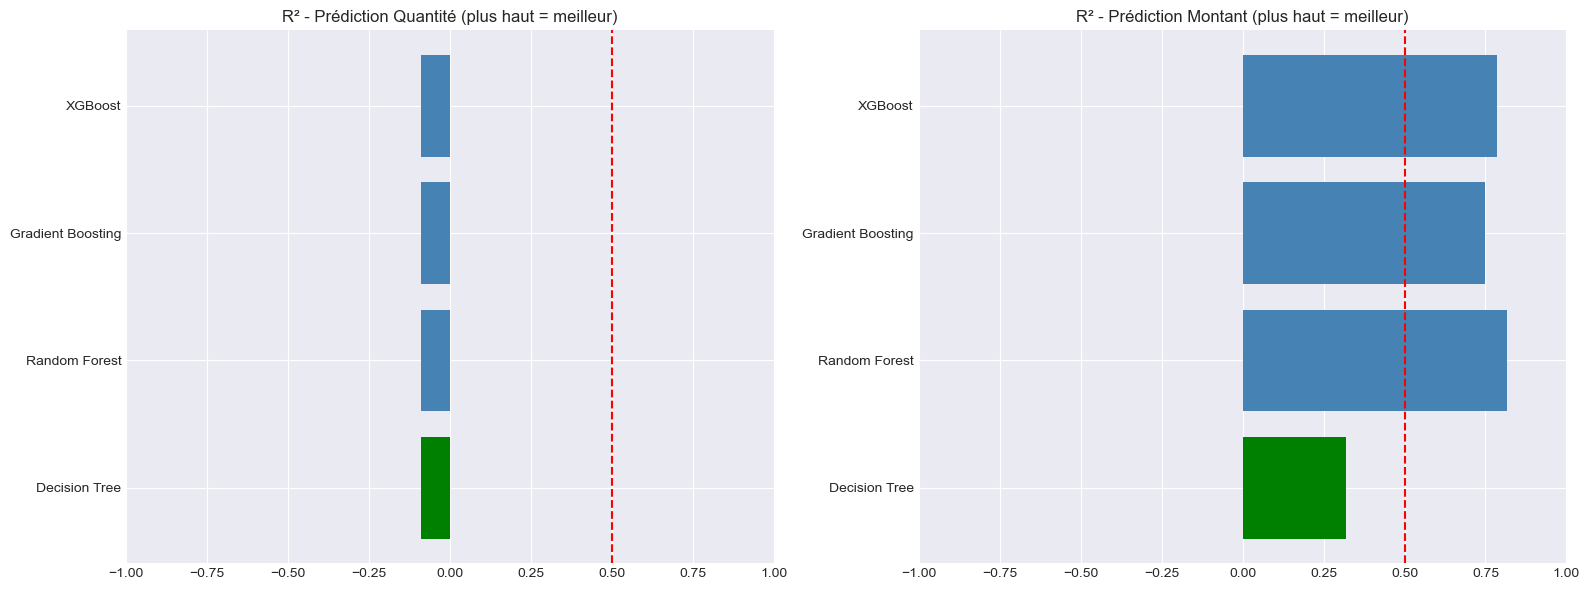


🏆 MEILLEUR MODÈLE - Quantité : Decision Tree (R² = -0.0909)
🏆 MEILLEUR MODÈLE - Montant : Random Forest (R² = 0.8170)


In [54]:
# CELLULE H : Comparaison des modèles

print("\n" + "="*70)
print("📊 COMPARAISON DES MODÈLES ML")
print("="*70)

# Collecter les résultats
results = []

# Decision Tree
results.append({'Modèle': 'Decision Tree', 'MAE_Q': mae_dt_q, 'R²_Q': r2_dt_q, 'MAE_A': mae_dt_a, 'R²_A': r2_dt_a})

# Random Forest
results.append({'Modèle': 'Random Forest', 'MAE_Q': mae_rf_q, 'R²_Q': r2_rf_q, 'MAE_A': mae_rf_a, 'R²_A': r2_rf_a})

# Gradient Boosting
results.append({'Modèle': 'Gradient Boosting', 'MAE_Q': mae_gb_q, 'R²_Q': r2_gb_q, 'MAE_A': mae_gb_a, 'R²_A': r2_gb_a})

# XGBoost
if 'mae_xgb_q' in locals() and mae_xgb_q != 0:
    results.append({'Modèle': 'XGBoost', 'MAE_Q': mae_xgb_q, 'R²_Q': r2_xgb_q, 'MAE_A': mae_xgb_a, 'R²_A': r2_xgb_a})

results_df = pd.DataFrame(results).sort_values('R²_Q', ascending=False)

print("\n📊 TABLEAU COMPARATIF - Quantité :")
print(results_df[['Modèle', 'MAE_Q', 'R²_Q']].to_string(index=False))

print("\n📊 TABLEAU COMPARATIF - Montant :")
print(results_df[['Modèle', 'MAE_A', 'R²_A']].to_string(index=False))

# Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² pour quantité
colors = ['green' if i == 0 else 'steelblue' for i in range(len(results_df))]
axes[0].barh(results_df['Modèle'], results_df['R²_Q'], color=colors)
axes[0].set_title('R² - Prédiction Quantité (plus haut = meilleur)', fontsize=12)
axes[0].axvline(x=0.5, color='red', linestyle='--')
axes[0].set_xlim(-1, 1)

# R² pour montant
axes[1].barh(results_df['Modèle'], results_df['R²_A'], color=colors)
axes[1].set_title('R² - Prédiction Montant (plus haut = meilleur)', fontsize=12)
axes[1].axvline(x=0.5, color='red', linestyle='--')
axes[1].set_xlim(-1, 1)

plt.tight_layout()
plt.show()

# Meilleur modèle
best_model_q = results_df.iloc[0]['Modèle']
best_r2_q = results_df.iloc[0]['R²_Q']
best_model_a = results_df.loc[results_df['R²_A'].idxmax(), 'Modèle']
best_r2_a = results_df['R²_A'].max()

print("\n" + "="*70)
print(f"🏆 MEILLEUR MODÈLE - Quantité : {best_model_q} (R² = {best_r2_q:.4f})")
print(f"🏆 MEILLEUR MODÈLE - Montant : {best_model_a} (R² = {best_r2_a:.4f})")
print("="*70)


📊 ANALYSE PAR MOIS
Mois avec promotions : 0
Total transactions avec promo : 0
⚠️ Aucune transaction avec promotion détectée
   → Affichage des ventes totales par mois


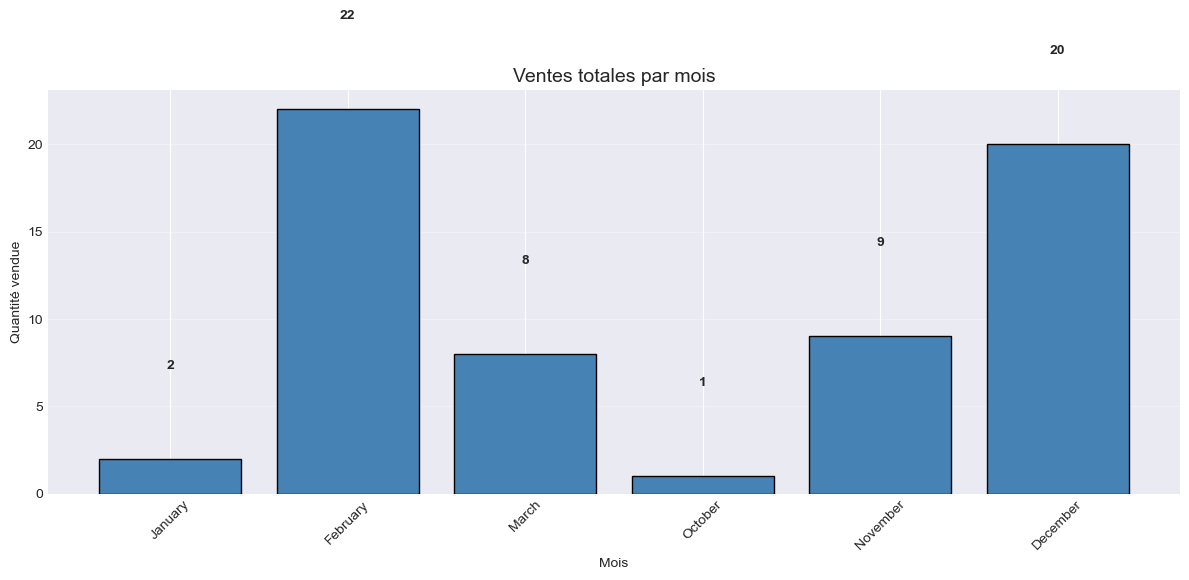


📅 MOIS AVEC LE PLUS DE VENTES :
   📌 February: 22 unités
   📌 December: 20 unités
   📌 November: 9 unités


In [30]:
# CELLULE M : Analyse par mois (VERSION RÉÉCRITE)

print("\n" + "="*70)
print("📊 ANALYSE PAR MOIS")
print("="*70)

# Ajouter le mois
df['month'] = df['full_date'].dt.month
df['month_name'] = df['full_date'].dt.strftime('%B')

# Vérifier combien de mois ont des promotions
months_with_promo = df[df['has_promotion'] == 1]['month_name'].nunique()
print(f"Mois avec promotions : {months_with_promo}")
print(f"Total transactions avec promo : {df['has_promotion'].sum()}")

if months_with_promo > 0:
    # Calculer la quantité moyenne avec et sans promotion par mois
    monthly_with_promo = df[df['has_promotion'] == 1].groupby('month_name')['quantity'].mean().reset_index()
    monthly_with_promo.columns = ['month_name', 'qty_with_promo']
    
    monthly_without_promo = df[df['has_promotion'] == 0].groupby('month_name')['quantity'].mean().reset_index()
    monthly_without_promo.columns = ['month_name', 'qty_without_promo']
    
    # Fusionner
    monthly_compare = pd.merge(monthly_with_promo, monthly_without_promo, on='month_name', how='outer').fillna(0)
    
    # Calculer l'augmentation
    monthly_compare['increase'] = ((monthly_compare['qty_with_promo'] - monthly_compare['qty_without_promo']) / monthly_compare['qty_without_promo'].replace(0, 1)) * 100
    
    # Trier par mois
    month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                   'July', 'August', 'September', 'October', 'November', 'December']
    monthly_compare['order'] = monthly_compare['month_name'].apply(lambda x: month_order.index(x) if x in month_order else 0)
    monthly_compare = monthly_compare.sort_values('order')
    
    # Graphique
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Graphique 1 : Augmentation par mois
    colors = ['green' if v > 0 else 'red' for v in monthly_compare['increase']]
    bars1 = axes[0].bar(monthly_compare['month_name'], monthly_compare['increase'], color=colors, edgecolor='black')
    axes[0].set_title('Augmentation des ventes avec promotion par mois (%)', fontsize=12)
    axes[0].set_xlabel('Mois')
    axes[0].set_ylabel('Augmentation (%)')
    axes[0].axhline(y=0, color='black', linestyle='-')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars1, monthly_compare['increase']):
        if val != 0:
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (2 if val > 0 else -5), 
                         f'{val:.0f}%', ha='center', va='bottom' if val > 0 else 'top', fontweight='bold')
    
    # Graphique 2 : Comparaison avec/sans promotion
    x = np.arange(len(monthly_compare))
    width = 0.35
    bars2 = axes[1].bar(x - width/2, monthly_compare['qty_without_promo'], width, 
                        label='Sans promotion', color='steelblue', edgecolor='black')
    bars3 = axes[1].bar(x + width/2, monthly_compare['qty_with_promo'], width, 
                        label='Avec promotion', color='coral', edgecolor='black')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(monthly_compare['month_name'], rotation=45)
    axes[1].set_title('Quantité moyenne par mois', fontsize=12)
    axes[1].set_xlabel('Mois')
    axes[1].set_ylabel('Quantité moyenne')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x)}'))
    
    plt.tight_layout()
    plt.show()
    
    # Afficher les meilleurs mois
    print("\n📅 MEILLEURS MOIS POUR LES PROMOTIONS :")
    best_months = monthly_compare[monthly_compare['qty_with_promo'] > 0].nlargest(3, 'increase')
    if len(best_months) > 0:
        for i, row in best_months.iterrows():
            icon = "🥇" if i == best_months.index[0] else "🥈" if i == best_months.index[1] else "🥉"
            print(f"   {icon} {row['month_name']}: +{row['increase']:.0f}% (de {row['qty_without_promo']:.1f} à {row['qty_with_promo']:.1f} unités)")
    else:
        print("   ⚠️ Aucune augmentation significative détectée")
        
else:
    print("⚠️ Aucune transaction avec promotion détectée")
    print("   → Affichage des ventes totales par mois")
    
    # Version alternative : ventes totales par mois
    monthly_sales = df.groupby('month_name')['quantity'].sum().reset_index()
    month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                   'July', 'August', 'September', 'October', 'November', 'December']
    monthly_sales['order'] = monthly_sales['month_name'].apply(lambda x: month_order.index(x) if x in month_order else 0)
    monthly_sales = monthly_sales.sort_values('order')
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(monthly_sales['month_name'], monthly_sales['quantity'], color='steelblue', edgecolor='black')
    plt.title('Ventes totales par mois', fontsize=14)
    plt.xlabel('Mois')
    plt.ylabel('Quantité vendue')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, monthly_sales['quantity']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 str(val), ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📅 MOIS AVEC LE PLUS DE VENTES :")
    top_months = monthly_sales.nlargest(3, 'quantity')
    for i, row in top_months.iterrows():
        print(f"   📌 {row['month_name']}: {row['quantity']} unités")


📊 TABLEAU RÉCAPITULATIF GRAPHIQUE DES PROMOTIONS


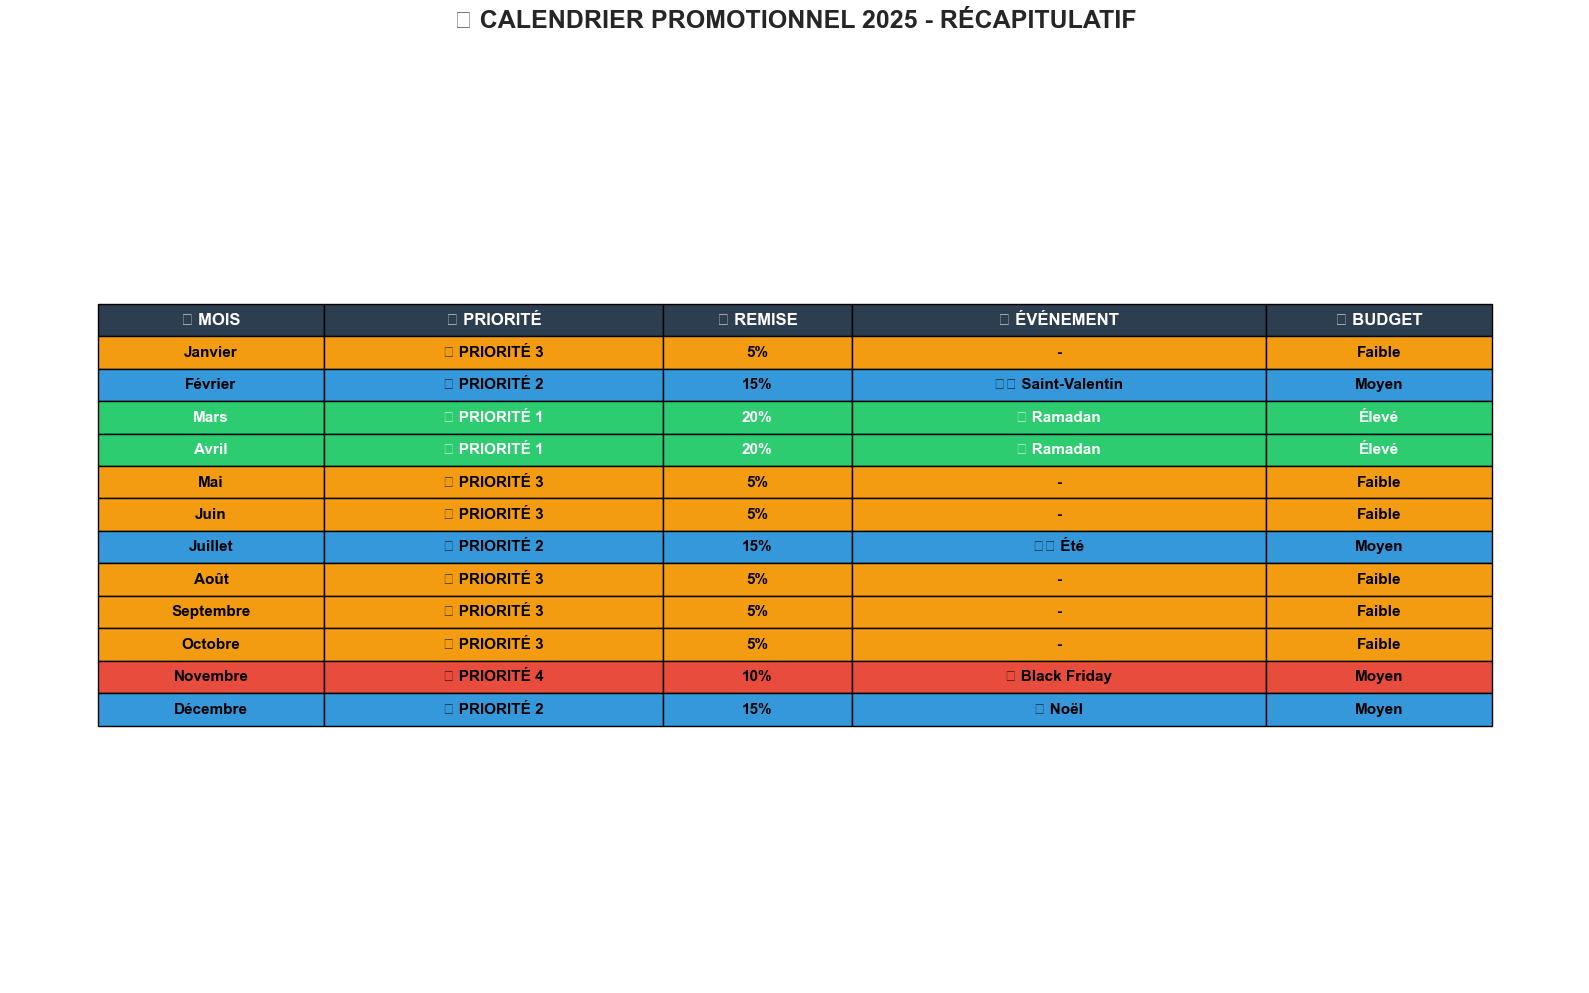

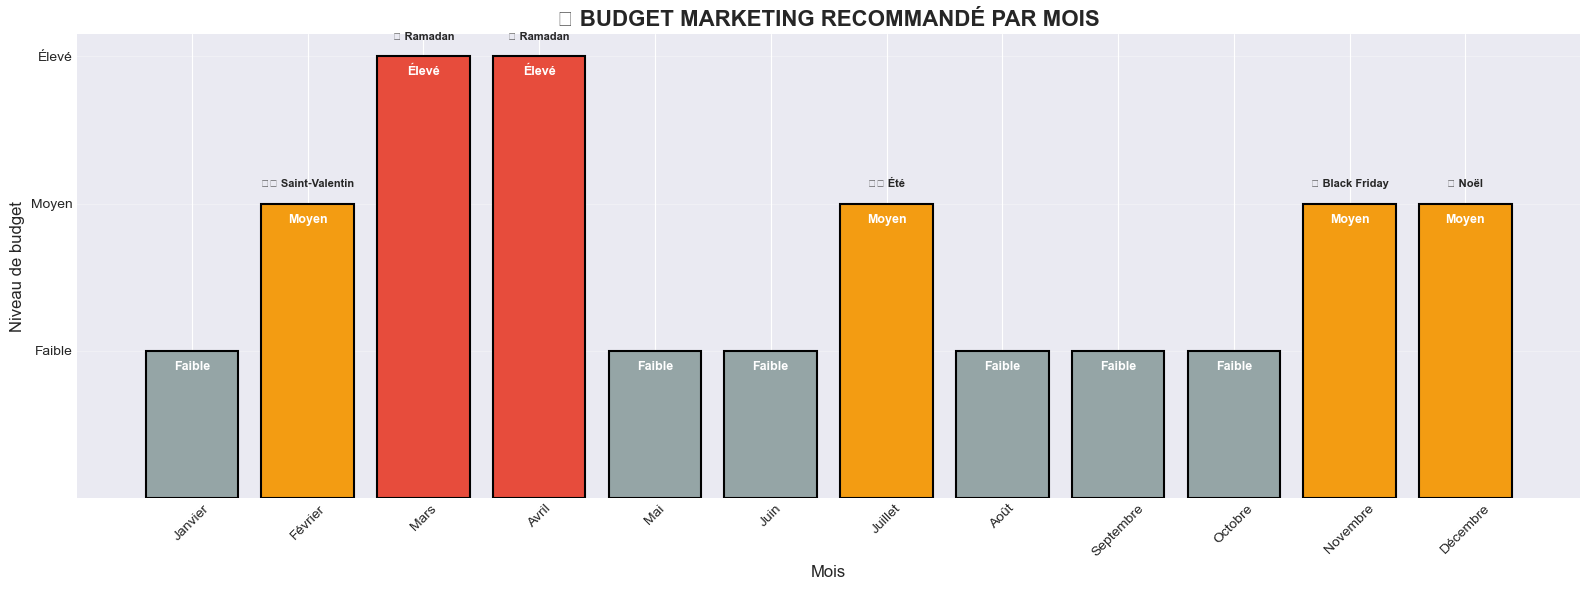

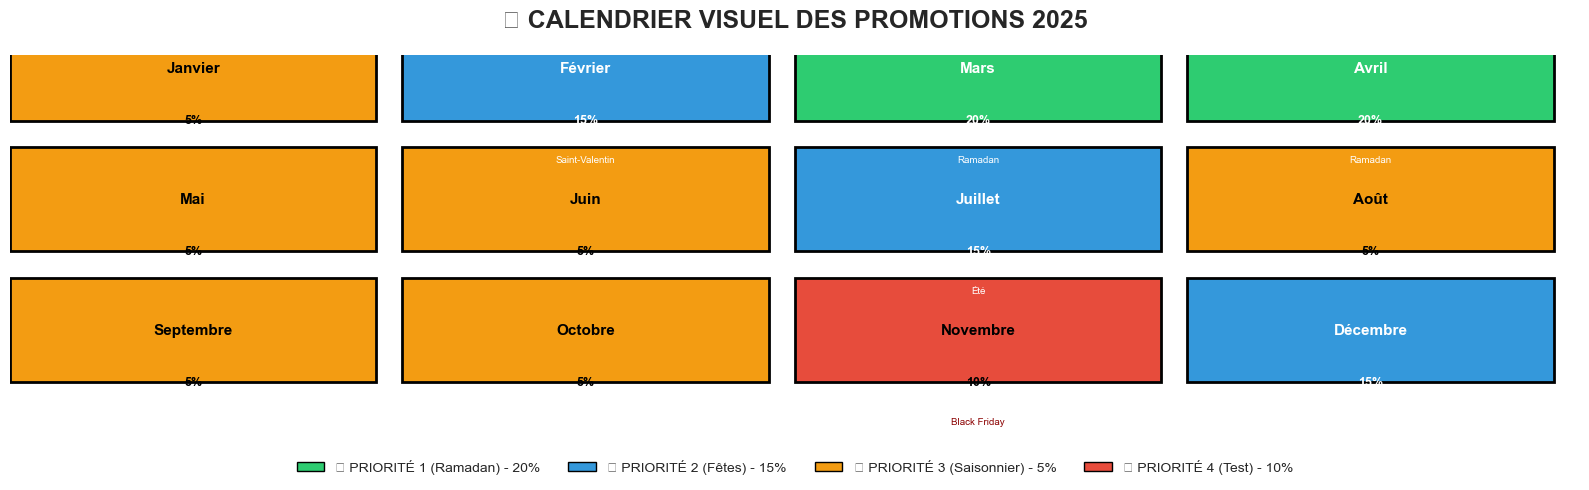

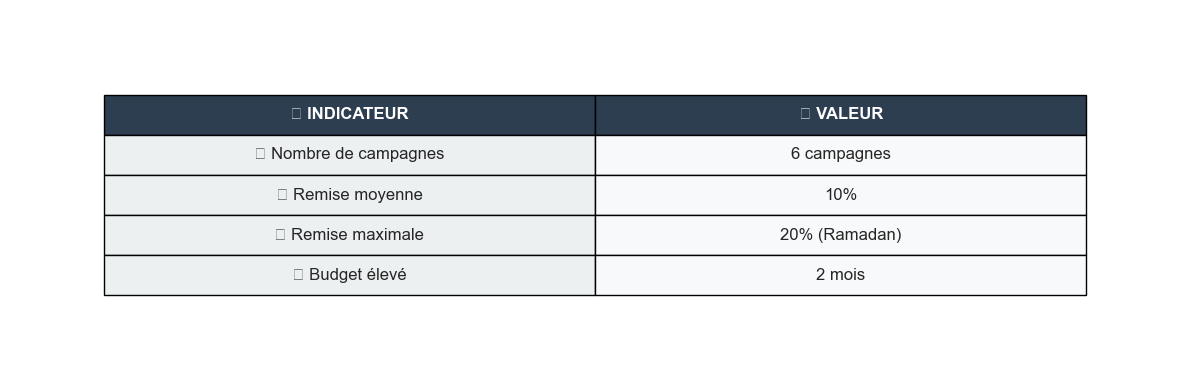


✅ Tableau récapitulatif graphique généré


In [43]:
# ============================================
# 11. TABLEAU RÉCAPITULATIF GRAPHIQUE DES PROMOTIONS
# ============================================

print("\n" + "="*70)
print("📊 TABLEAU RÉCAPITULATIF GRAPHIQUE DES PROMOTIONS")
print("="*70)

# Créer les données pour le graphique
recap_data = pd.DataFrame({
    'Mois': ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin', 
             'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre'],
    'Priorite': [3, 2, 1, 1, 3, 3, 2, 3, 3, 3, 4, 2],
    'Remise': [5, 15, 20, 20, 5, 5, 15, 5, 5, 5, 10, 15],
    'Evenement': ['-', '❤️ Saint-Valentin', '🌙 Ramadan', '🌙 Ramadan', '-', '-', 
                  '☀️ Été', '-', '-', '-', '🎯 Black Friday', '🎄 Noël'],
    'Budget': ['Faible', 'Moyen', 'Élevé', 'Élevé', 'Faible', 'Faible', 
               'Moyen', 'Faible', 'Faible', 'Faible', 'Moyen', 'Moyen']
})

# Couleurs par priorité
priority_colors = {1: '#2ecc71', 2: '#3498db', 3: '#f39c12', 4: '#e74c3c'}
priority_names = {1: '🔴 PRIORITÉ 1', 2: '🟠 PRIORITÉ 2', 3: '🟡 PRIORITÉ 3', 4: '🟢 PRIORITÉ 4'}

# ============================================
# GRAPHIQUE 1 : TABLEAU VISUEL (Heatmap)
# ============================================
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

# Créer les données du tableau
table_data = []
row_colors = []

for _, row in recap_data.iterrows():
    priority_color = priority_colors[row['Priorite']]
    row_colors.append([priority_color] * 5)  # 5 colonnes
    
    table_data.append([
        row['Mois'],
        priority_names[row['Priorite']],
        f"{row['Remise']}%",
        row['Evenement'],
        row['Budget']
    ])

# Créer le tableau
table = ax.table(cellText=table_data,
                  colLabels=['📅 MOIS', '🎯 PRIORITÉ', '💰 REMISE', '🎉 ÉVÉNEMENT', '💶 BUDGET'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.12, 0.18, 0.10, 0.22, 0.12])

# Styliser le tableau
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.6)

# Colorer l'en-tête
for i in range(5):
    table[(0, i)].set_facecolor('#2c3e50')
    table[(0, i)].set_text_props(color='white', fontweight='bold', fontsize=12)

# Colorer les lignes selon la priorité
for i in range(len(table_data)):
    for j in range(5):
        table[(i+1, j)].set_facecolor(row_colors[i][j])
        table[(i+1, j)].set_text_props(color='white' if i in [2,3] else 'black', fontweight='bold')

# Ajouter un titre
ax.text(0.5, 1.02, '📅 CALENDRIER PROMOTIONNEL 2025 - RÉCAPITULATIF', 
        transform=ax.transAxes, fontsize=18, fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

# ============================================
# GRAPHIQUE 2 : TABLEAU SOUS FORME DE BARRES (Budget)
# ============================================
fig, ax = plt.subplots(figsize=(16, 6))

# Créer un mapping des budgets
budget_map = {'Faible': 1, 'Moyen': 2, 'Élevé': 3}
budget_colors = {'Faible': '#95a5a6', 'Moyen': '#f39c12', 'Élevé': '#e74c3c'}

budget_values = [budget_map[b] for b in recap_data['Budget']]
budget_colors_list = [budget_colors[b] for b in recap_data['Budget']]

bars = ax.bar(recap_data['Mois'], budget_values, color=budget_colors_list, edgecolor='black', linewidth=1.5)
ax.set_title('💰 BUDGET MARKETING RECOMMANDÉ PAR MOIS', fontsize=16, fontweight='bold')
ax.set_xlabel('Mois', fontsize=12)
ax.set_ylabel('Niveau de budget', fontsize=12)
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['Faible', 'Moyen', 'Élevé'])
ax.tick_params(axis='x', rotation=45)

# Ajouter les événements sur les barres
for bar, evenement in zip(bars, recap_data['Evenement']):
    if evenement != '-':
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                evenement, ha='center', va='bottom', fontsize=8, fontweight='bold', rotation=0)

# Ajouter les valeurs
for bar, val in zip(bars, budget_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.15, 
            ['Faible', 'Moyen', 'Élevé'][val-1], ha='center', va='bottom', 
            fontweight='bold', fontsize=9, color='white')

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================
# GRAPHIQUE 3 : TABLEAU SOUS FORME DE CALENDRIER (Couleurs)
# ============================================
fig, ax = plt.subplots(figsize=(16, 8))

# Créer une grille 3x4 pour les mois
months_2d = [
    ['Janvier', 'Février', 'Mars', 'Avril'],
    ['Mai', 'Juin', 'Juillet', 'Août'],
    ['Septembre', 'Octobre', 'Novembre', 'Décembre']
]

for i in range(3):
    for j in range(4):
        mois = months_2d[i][j]
        data = recap_data[recap_data['Mois'] == mois].iloc[0]
        
        # Déterminer la couleur selon priorité
        color = priority_colors[data['Priorite']]
        
        # Créer la case
        rect = plt.Rectangle((j*3, 2.5-i), 2.8, 0.8, facecolor=color, edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        
        # Ajouter le nom du mois
        ax.text(j*3 + 1.4, 2.9 - i, mois, ha='center', va='center', 
                fontweight='bold', fontsize=11, color='white' if data['Priorite'] <= 2 else 'black')
        
        # Ajouter la remise
        ax.text(j*3 + 1.4, 2.5 - i, f"{data['Remise']}%", ha='center', va='center', 
                fontsize=9, fontweight='bold', color='white' if data['Priorite'] <= 2 else 'black')
        
        # Ajouter l'événement
        if data['Evenement'] != '-':
            event_text = data['Evenement'].replace('❤️ ', '').replace('🌙 ', '').replace('☀️ ', '').replace('🎯 ', '').replace('🎄 ', '')
            ax.text(j*3 + 1.4, 2.2 - i, event_text, ha='center', va='center', 
                    fontsize=7, color='white' if data['Priorite'] <= 2 else 'darkred')

ax.set_xlim(0, 12)
ax.set_ylim(0, 3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('📅 CALENDRIER VISUEL DES PROMOTIONS 2025', fontsize=18, fontweight='bold', pad=20)

# Ajouter une légende
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='🔴 PRIORITÉ 1 (Ramadan) - 20%'),
    Patch(facecolor='#3498db', edgecolor='black', label='🟠 PRIORITÉ 2 (Fêtes) - 15%'),
    Patch(facecolor='#f39c12', edgecolor='black', label='🟡 PRIORITÉ 3 (Saisonnier) - 5%'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='🟢 PRIORITÉ 4 (Test) - 10%')
]
ax.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=10)

plt.tight_layout()
plt.show()

# ============================================
# GRAPHIQUE 4 : RÉSUMÉ DES STATISTIQUES
# ============================================
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

# Calculer les statistiques
total_promo = len(recap_data[recap_data['Evenement'] != '-'])
avg_remise = recap_data['Remise'].mean()
max_remise = recap_data['Remise'].max()
high_budget = len(recap_data[recap_data['Budget'] == 'Élevé'])

# Créer un tableau récapitulatif
stats_data = [
    ["📊 Nombre de campagnes", f"{total_promo} campagnes"],
    ["💰 Remise moyenne", f"{avg_remise:.0f}%"],
    ["🏆 Remise maximale", f"{max_remise}% (Ramadan)"],
    ["💶 Budget élevé", f"{high_budget} mois"]
]

stats_table = ax.table(cellText=stats_data,
                        colLabels=['📈 INDICATEUR', '📊 VALEUR'],
                        cellLoc='center',
                        loc='center',
                        colWidths=[0.35, 0.35])

stats_table.auto_set_font_size(False)
stats_table.set_fontsize(12)
stats_table.scale(1.2, 2)

for i in range(2):
    stats_table[(0, i)].set_facecolor('#2c3e50')
    stats_table[(0, i)].set_text_props(color='white', fontweight='bold')

for i in range(1, len(stats_data)+1):
    stats_table[(i, 0)].set_facecolor('#ecf0f1')
    stats_table[(i, 1)].set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✅ Tableau récapitulatif graphique généré")
print("="*70)


📊 STRATÉGIE PROMOTIONNELLE PERSONNALISÉE


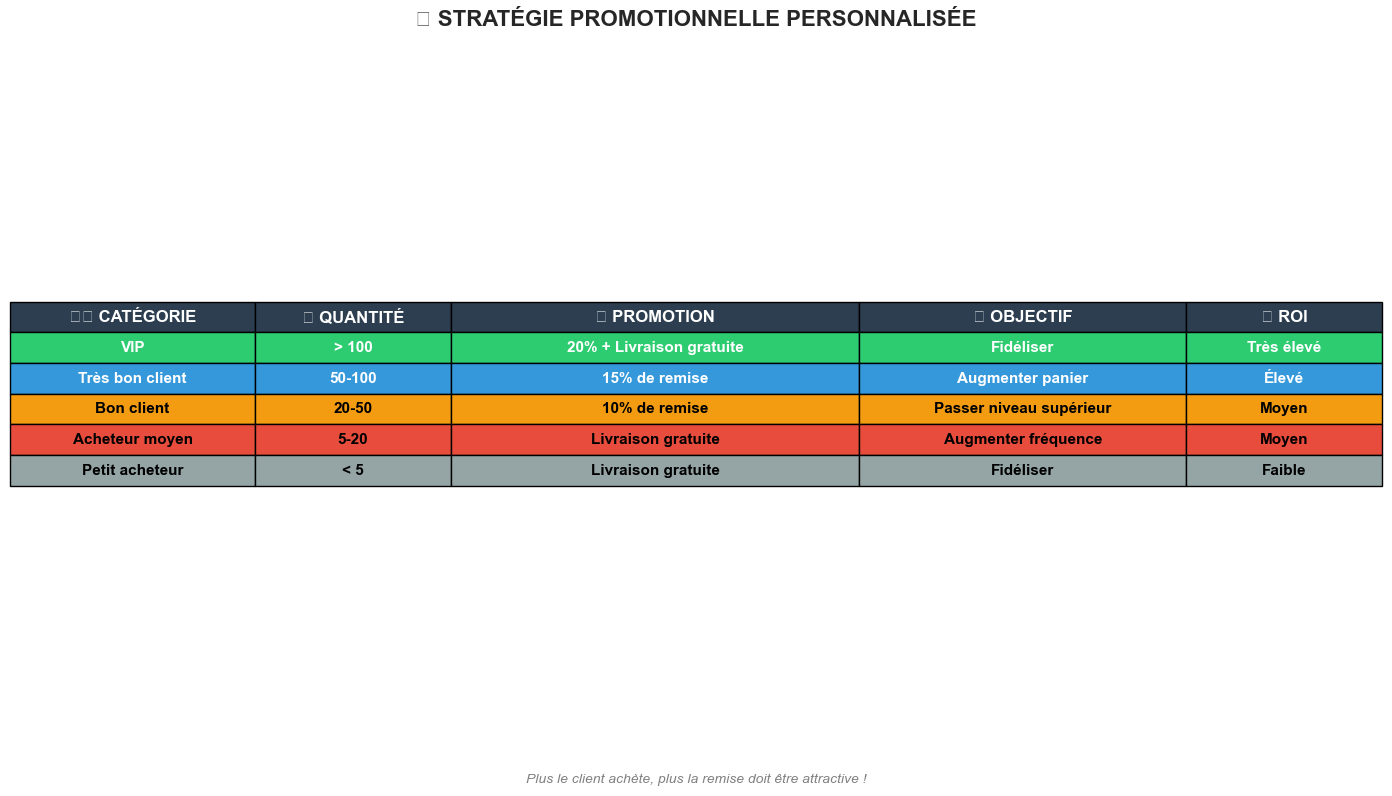

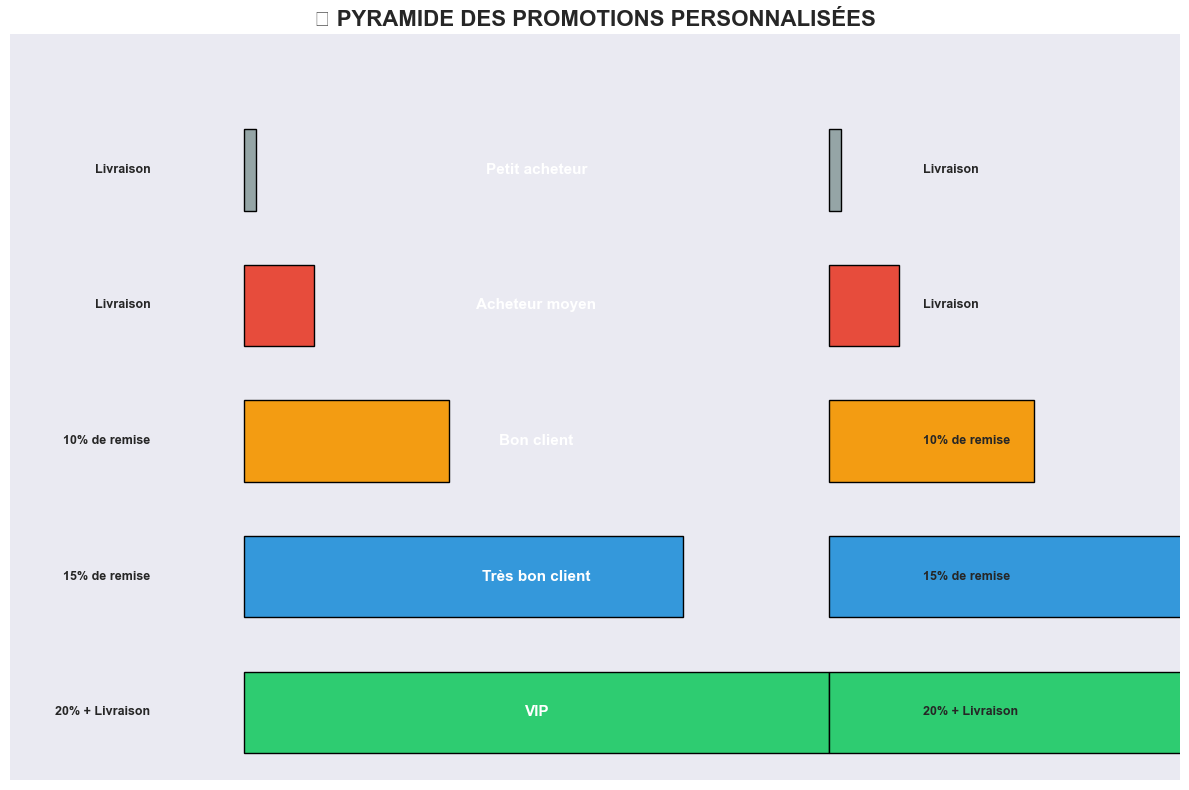

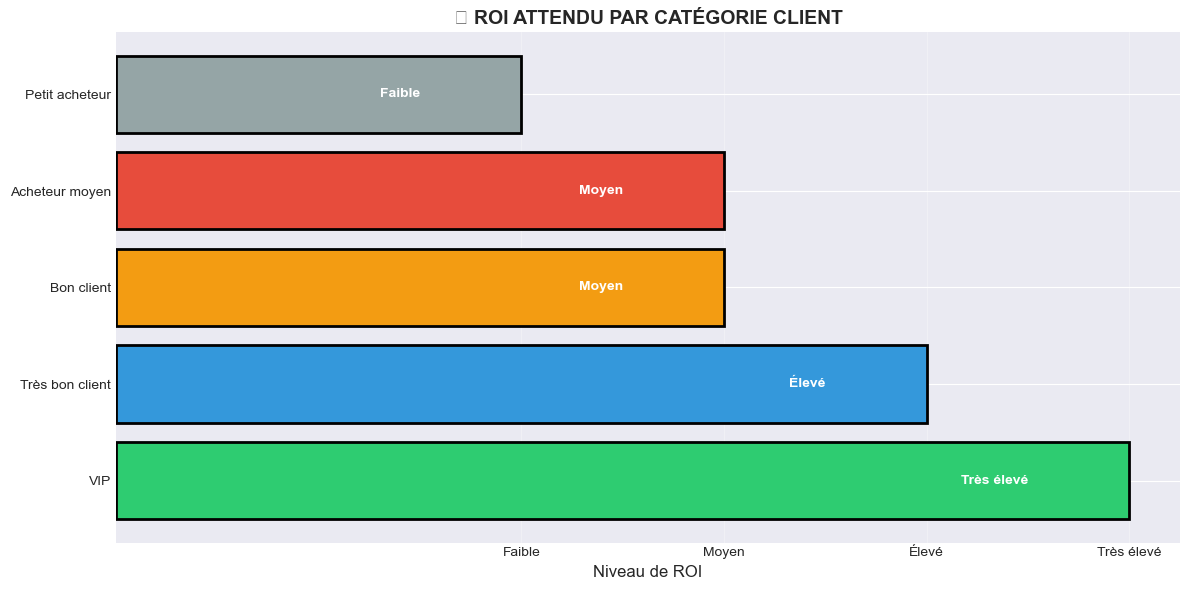

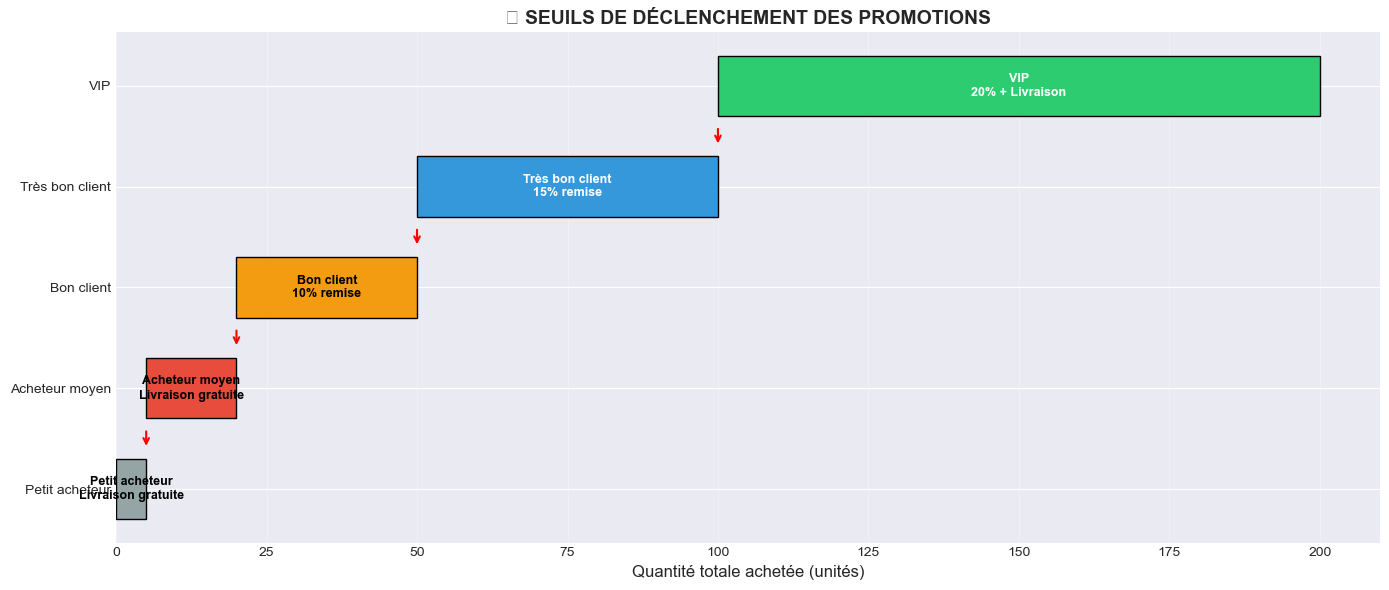


✅ Graphiques de la stratégie promotionnelle générés


In [44]:
# ============================================
# STRATÉGIE PROMOTIONNELLE PERSONNALISÉE - GRAPHIQUE
# ============================================

print("\n" + "="*70)
print("📊 STRATÉGIE PROMOTIONNELLE PERSONNALISÉE")
print("="*70)

# Données de la stratégie
strategie_data = pd.DataFrame({
    'Catégorie': ['VIP', 'Très bon client', 'Bon client', 'Acheteur moyen', 'Petit acheteur'],
    'Quantité': ['> 100', '50-100', '20-50', '5-20', '< 5'],
    'Promotion': ['20% + Livraison\ngratuite', '15% de remise', '10% de remise', 
                  'Livraison\ngratuite', 'Livraison\ngratuite'],
    'Objectif': ['Fidéliser', 'Augmenter\npanier', 'Passer niveau\nsupérieur', 
                 'Augmenter\nfréquence', 'Fidéliser'],
    'ROI': ['Très élevé', 'Élevé', 'Moyen', 'Moyen', 'Faible'],
    'Couleur': ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']
})

# ============================================
# GRAPHIQUE 1 : TABLEAU COLORÉ
# ============================================
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')

# Préparer les données du tableau
table_data = []
row_colors = []

for _, row in strategie_data.iterrows():
    row_colors.append([row['Couleur']] * 5)
    table_data.append([
        row['Catégorie'],
        row['Quantité'],
        row['Promotion'].replace('\n', ' '),
        row['Objectif'].replace('\n', ' '),
        row['ROI']
    ])

# Créer le tableau
table = ax.table(cellText=table_data,
                  colLabels=['🏷️ CATÉGORIE', '📦 QUANTITÉ', '🎁 PROMOTION', '🎯 OBJECTIF', '📈 ROI'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.15, 0.12, 0.25, 0.20, 0.12])

# Styliser le tableau
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.6)

# Colorer l'en-tête
for i in range(5):
    table[(0, i)].set_facecolor('#2c3e50')
    table[(0, i)].set_text_props(color='white', fontweight='bold', fontsize=12)

# Colorer les lignes selon la catégorie
for i in range(len(table_data)):
    for j in range(5):
        table[(i+1, j)].set_facecolor(row_colors[i][j])
        # Texte en blanc pour les couleurs foncées
        text_color = 'white' if i <= 1 else 'black'
        table[(i+1, j)].set_text_props(color=text_color, fontweight='bold')

# Ajouter un titre
ax.text(0.5, 1.02, '🎯 STRATÉGIE PROMOTIONNELLE PERSONNALISÉE', 
        transform=ax.transAxes, fontsize=16, fontweight='bold', ha='center')

# Ajouter une note
ax.text(0.5, -0.05, 'Plus le client achète, plus la remise doit être attractive !', 
        transform=ax.transAxes, fontsize=10, ha='center', color='gray', fontstyle='italic')

plt.tight_layout()
plt.show()

# ============================================
# GRAPHIQUE 2 : PYRAMIDE DES PROMOTIONS
# ============================================
fig, ax = plt.subplots(figsize=(12, 8))

# Créer la pyramide
categories = strategie_data['Catégorie'].tolist()
quantities = [100, 75, 35, 12, 2]  # Position y
colors_pyramid = strategie_data['Couleur'].tolist()
promotions = strategie_data['Promotion'].tolist()

# Dessiner les barres horizontales
for i, (cat, qty, color, promo) in enumerate(zip(categories, quantities, colors_pyramid, promotions)):
    # Barre de gauche (quantité)
    bar_left = ax.barh(i, qty/2, left=0, color=color, edgecolor='black', height=0.6)
    # Barre de droite (miroir)
    bar_right = ax.barh(i, qty/2, left=50, color=color, edgecolor='black', height=0.6)
    
    # Ajouter le texte
    ax.text(25, i, cat, ha='center', va='center', fontweight='bold', fontsize=11, color='white')
    ax.text(-8, i, promo.split('\n')[0], ha='right', va='center', fontsize=9, fontweight='bold')
    ax.text(58, i, promo.split('\n')[0] if len(promo.split('\n')) == 1 else promo.split('\n')[0], 
            ha='left', va='center', fontsize=9, fontweight='bold')

ax.set_xlim(-20, 80)
ax.set_ylim(-0.5, len(categories))
ax.set_yticks([])
ax.set_xticks([])
ax.set_title('🏆 PYRAMIDE DES PROMOTIONS PERSONNALISÉES', fontsize=16, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================
# GRAPHIQUE 3 : ROI PAR CATÉGORIE
# ============================================
fig, ax = plt.subplots(figsize=(12, 6))

roi_map = {'Très élevé': 5, 'Élevé': 4, 'Moyen': 3, 'Faible': 2}
roi_values = [roi_map[r] for r in strategie_data['ROI']]
colors_roi = strategie_data['Couleur'].tolist()

bars = ax.barh(strategie_data['Catégorie'], roi_values, color=colors_roi, edgecolor='black', linewidth=2)
ax.set_xlabel('Niveau de ROI', fontsize=12)
ax.set_title('📈 ROI ATTENDU PAR CATÉGORIE CLIENT', fontsize=14, fontweight='bold')
ax.set_xticks([2, 3, 4, 5])
ax.set_xticklabels(['Faible', 'Moyen', 'Élevé', 'Très élevé'])
ax.grid(True, alpha=0.3, axis='x')

for bar, roi in zip(bars, strategie_data['ROI']):
    ax.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2, 
            roi, ha='right', va='center', fontweight='bold', fontsize=10, color='white')

plt.tight_layout()
plt.show()

# ============================================
# GRAPHIQUE 4 : SEUILS VISUELS
# ============================================
fig, ax = plt.subplots(figsize=(14, 6))

# Créer une frise chronologique des seuils
seuils = [
    {'categorie': 'Petit acheteur', 'min': 0, 'max': 5, 'color': '#95a5a6', 'promo': 'Livraison gratuite'},
    {'categorie': 'Acheteur moyen', 'min': 5, 'max': 20, 'color': '#e74c3c', 'promo': 'Livraison gratuite'},
    {'categorie': 'Bon client', 'min': 20, 'max': 50, 'color': '#f39c12', 'promo': '10% remise'},
    {'categorie': 'Très bon client', 'min': 50, 'max': 100, 'color': '#3498db', 'promo': '15% remise'},
    {'categorie': 'VIP', 'min': 100, 'max': 200, 'color': '#2ecc71', 'promo': '20% + Livraison'}
]

for i, seuil in enumerate(seuils):
    width = seuil['max'] - seuil['min']
    bar = ax.barh(i, width, left=seuil['min'], color=seuil['color'], edgecolor='black', height=0.6)
    
    # Ajouter le texte
    ax.text(seuil['min'] + width/2, i, f"{seuil['categorie']}\n{seuil['promo']}", 
            ha='center', va='center', fontweight='bold', fontsize=9, 
            color='white' if i >= 3 else 'black')

ax.set_yticks(range(len(seuils)))
ax.set_yticklabels([s['categorie'] for s in seuils])
ax.set_xlabel('Quantité totale achetée (unités)', fontsize=12)
ax.set_title('📊 SEUILS DE DÉCLENCHEMENT DES PROMOTIONS', fontsize=14, fontweight='bold')
ax.set_xlim(0, 210)
ax.grid(True, alpha=0.3, axis='x')

# Ajouter les flèches indicatrices
for i, seuil in enumerate(seuils[:-1]):
    ax.annotate('', xy=(seuil['max'], i+0.4), xytext=(seuil['max'], i+0.6),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✅ Graphiques de la stratégie promotionnelle générés")
print("="*70)